In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

print("Libraries Loaded & Ready!")

Libraries Loaded & Ready!


In [ ]:
from google.colab import files
import io

# 1. X_train.csv
print("Please upload 'X_train.csv'")
uploaded_X_train = files.upload()
X_train = pd.read_csv(io.BytesIO(uploaded_X_train[list(uploaded_X_train.keys())[0]]))
print(f"-> Loaded {len(X_train)} training rows")

# 2. X_test.csv
print("Please upload 'X_test.csv'")
uploaded_X_test = files.upload()
X_test = pd.read_csv(io.BytesIO(uploaded_X_test[list(uploaded_X_test.keys())[0]]))
print(f"-> Loaded {len(X_test)} testing rows")

# 3. y_train.csv
print("Please upload 'y_train.csv'")
uploaded_Y_train = files.upload()
# Add .values.ravel() to flatten the 1D array
y_train = pd.read_csv(io.BytesIO(uploaded_Y_train[list(uploaded_Y_train.keys())[0]])).values.ravel()
print(f"-> Loaded {len(y_train)} training rows")

# 4. y_test.csv
print("Please upload 'y_test.csv'")
uploaded_Y_test = files.upload()
# Add .values.ravel() to flatten the 1D array
y_test = pd.read_csv(io.BytesIO(uploaded_Y_test[list(uploaded_Y_test.keys())[0]])).values.ravel()
print(f"-> Loaded {len(y_test)} testing rows")

print("\n🎉 All Data Successfully Loaded!")

Please upload 'X_train.csv'


Saving X_train.csv to X_train (20).csv
-> Loaded 153 training rows
Please upload 'X_test.csv'


Saving X_test.csv to X_test.csv
-> Loaded 39 testing rows
Please upload 'y_train.csv'


Saving y_train.csv to y_train.csv
-> Loaded 153 training rows
Please upload 'y_test.csv'


Saving y_test.csv to y_test.csv
-> Loaded 39 testing rows

🎉 All Data Successfully Loaded!


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight = "balanced"
    )
#n_estimatomers=200 --> number of trees
#max_depth=5 --> keeps trees simple
#random_state=42 --> reproducible results
#class_weight = "balanced" --> handles imblanced data

print("✅ Model Structure Created!")

✅ Model Structure Created!


In [ ]:
#Train the models
print("Training the model...(this might take a few seconds)")

model.fit(X_train, y_train)
print("Training completed The model has learned the patterns.")

Training the model...(this might take a few seconds)
Training completed The model has learned the patterns.


In [ ]:
#Test the Model
# 1. Create predictions variable
predictions = model.predict(X_test)

# 2. Create probabilities variable (get the HIGH RISK probability [:, 1])
probabilities = model.predict_proba(X_test)[:, 1]

# 3. Print analysis
high_risk_zips = np.sum(predictions == 1)
low_risk_zips = np.sum(predictions == 0)

print("✅ Predictions Generated!")
print(f"Predicted HIGH RISK ZIPs: {high_risk_zips}")
print(f"Predicted LOW RISK ZIPs: {low_risk_zips}")


✅ Predictions Generated!
Predicted HIGH RISK ZIPs: 14
Predicted LOW RISK ZIPs: 25


In [ ]:
# 1. Calculate Accuracy
accuracy = accuracy_score(Y_test, predictions)

# 2. Calculate ROC-AUC
roc_auc = roc_auc_score(Y_test, probabilities)

# 3. Determine Letter Grade based on ROC-AUC
if roc_auc >= 0.85:
    grade = "A (Excellent Model)"
elif roc_auc >= 0.75:
    grade = "B (Good Model)"
elif roc_auc >= 0.60:
    grade = "C (Fair Model)"
else:
    grade = "D (Poor Model)"

# Create the formatted report card
print("================ MODEL REPORT CARD ================")
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"ROC-AUC: {roc_auc:.3f}")
print("--------------------------------")
print(f"\n⭐ GRADE: {grade}\n")
print("===================================================")

================ MODEL REPORT CARD ================
Accuracy: 89.7%
ROC-AUC: 0.976
--------------------------------

⭐ GRADE: A (Excellent Model)



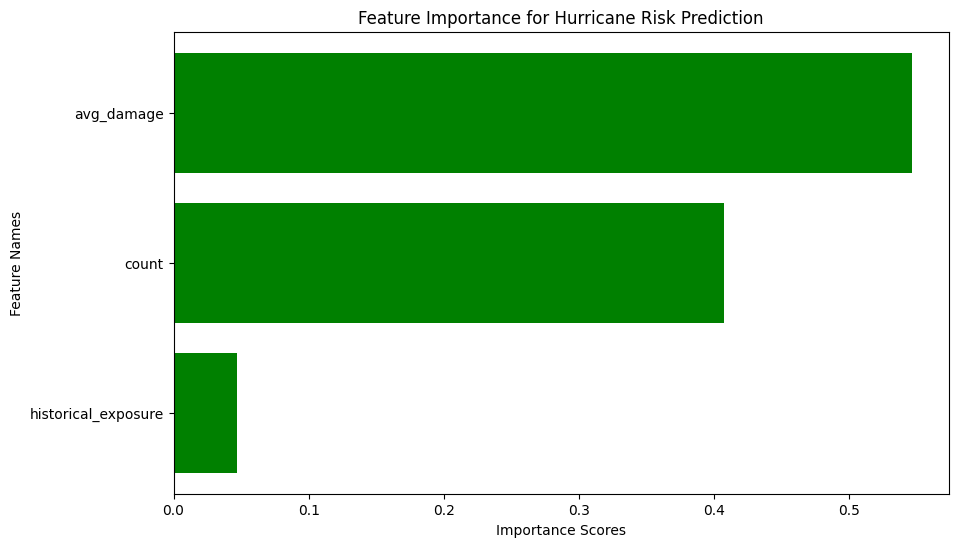

🧙 The #1 most important predictor was: avg_damage


In [ ]:
# 1. Extract feature importance
importance = model.feature_importances_

# 2. Get the feature names
feature_names = X_train.columns

# 3. Sort the importances using np.argsort()
sorted_ind = np.argsort(importances)
sorted_importances = importances[sorted_ind]
sorted_feature_names = feature_names[sorted_ind]

# 4. Create a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, sorted_importances, color='green')
plt.title('Feature Importance for Hurricane Risk Prediction')
plt.xlabel('Importance Scores')
plt.ylabel('Feature Names')
plt.show()

# 5. Print which feature is #1 most important
most_important_feature = sorted_feature_names[-1]

print(f"🧙 The #1 most important predictor was: {most_important_feature}")